In [1]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [3]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [4]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [5]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [6]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [7]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)

    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [8]:
u_L_vect = np.array(u_L.vector().get_local())

In [9]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [10]:
uh_HDM_sol_vec.shape

(160801,)

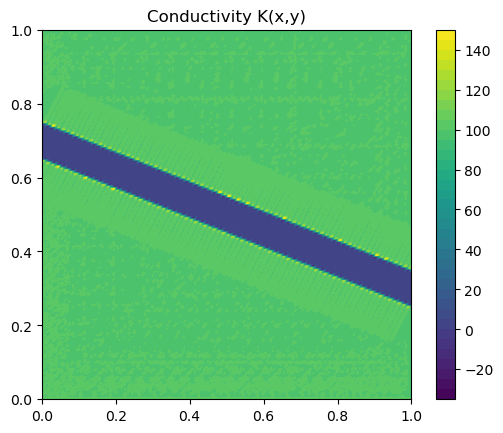

In [11]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="viridis")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")
    plt.show()

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

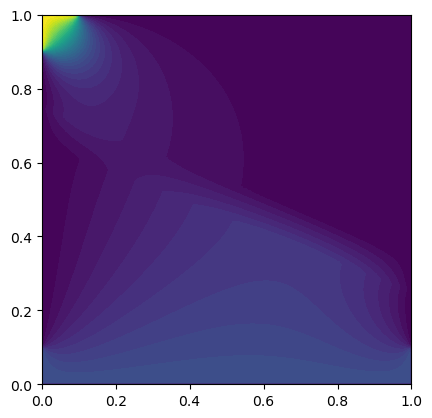

In [12]:
plot(uh_HDM_sol)

In [13]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [ ]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

Génération des Snapshots:   0%|          | 0/30 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   3%|▎         | 1/30 [00:05<02:53,  6.00s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   7%|▋         | 2/30 [00:10<02:31,  5.40s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  27%|██▋       | 8/30 [00:38<01:39,  4.53s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  30%|███       | 9/30 [00:43<01:35,  4.57s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


In [ ]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

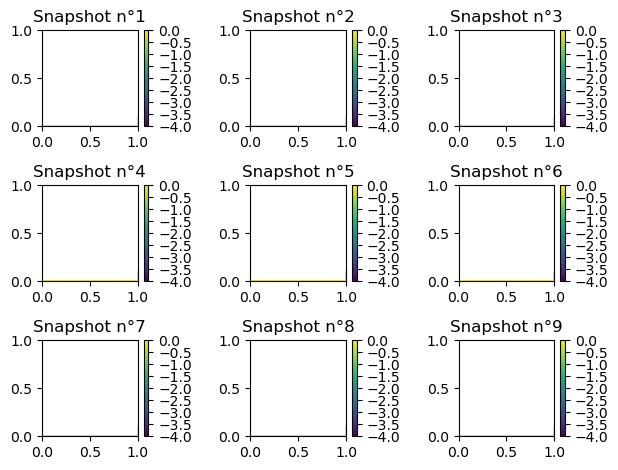

In [ ]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [ ]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



number of singular values: 30
U shape: (160801, 30)
S shape: (30,)
Vt shape: (30, 30)
Singular values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


/usr/local/Caskroom/miniforge/base/envs/projet_darcy/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


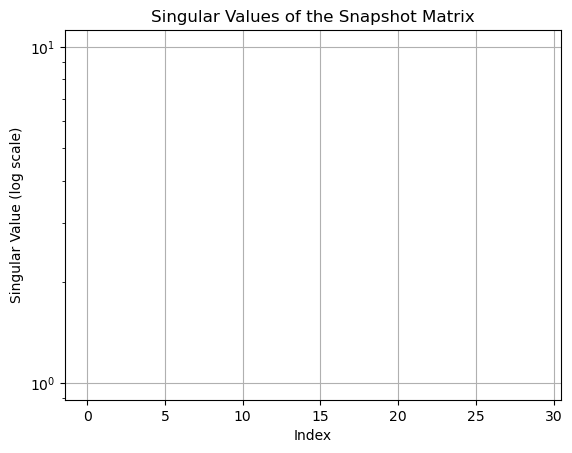

In [ ]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
def plot_energy_contribution(S):
    energy = S**2
    print("Energy (squared singular values):", energy)
    cumulative_energy = np.cumsum(energy)
    print("Cumulative energy:", cumulative_energy)
    total_energy = cumulative_energy[-1]
    print("Total energy:", total_energy)
    energy_percentage = cumulative_energy / total_energy * 100
    print("Energy percentage:", energy_percentage)
    
    plt.figure(figsize=(8, 5))
    plt.plot(energy_percentage, marker='o')
    
    # --- LA CORRECTION EST ICI ---
    # On force l'axe Y à aller de 0 à 105% (ou 90 à 105% si tu préfères)
    plt.ylim(min(energy_percentage[0], 99), 100) 
    
    plt.xlabel('Number of Modes')
    plt.ylabel('Cumulative Energy (%)')
    plt.title('Cumulative Energy Contribution of Singular Values')
    plt.grid()
    plt.show()


Energy (squared singular values): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Cumulative energy: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Total energy: 0.0
Energy percentage: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]


/var/folders/qc/1bs3nfys4q37gmwmx3j9xnk40000gn/T/ipykernel_20734/1722573203.py:8: RuntimeWarning: invalid value encountered in divide
  energy_percentage = cumulative_energy / total_energy * 100


ValueError: Axis limits cannot be NaN or Inf

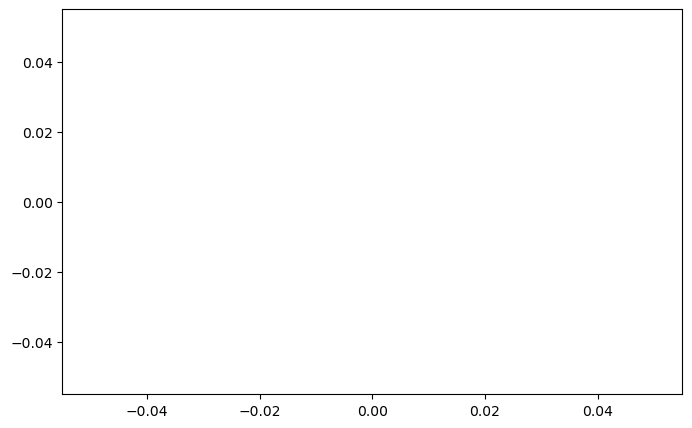

In [ ]:
plot_energy_contribution(S)

## Un premier test

Time for ROM solve: 0.21830987930297852 seconds
Time for full HDM solve: 1.3199958801269531 seconds


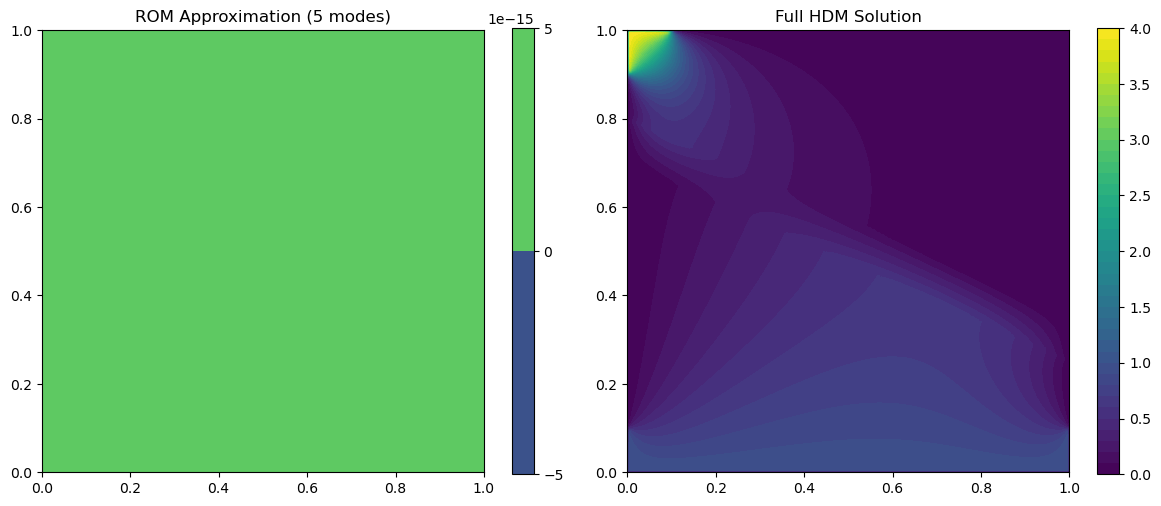

In [ ]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, cmap="viridis")
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, cmap="viridis")
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser


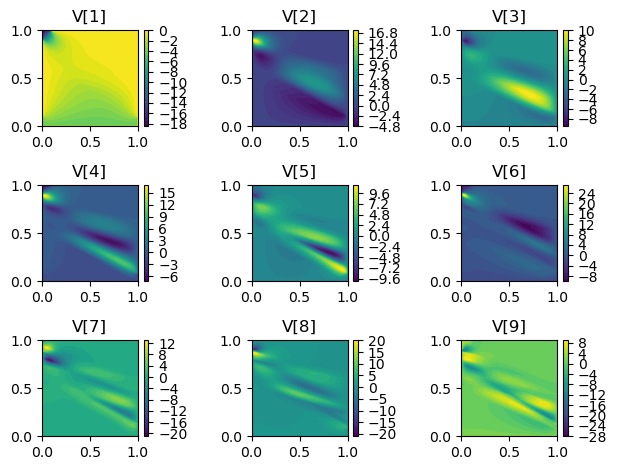

In [ ]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [ ]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

Error with 1 modes: 1.0910e-01
Error with 2 modes: 1.1383e-01
Error with 3 modes: 7.7509e-02
Error with 4 modes: 7.6534e-02
Error with 5 modes: 7.6497e-02
Error with 6 modes: 8.4902e-02
Error with 7 modes: 8.4787e-02
Error with 8 modes: 8.1396e-02
Error with 9 modes: 8.1107e-02
Error with 10 modes: 7.9087e-02
Error with 11 modes: 7.8972e-02
Error with 12 modes: 7.8629e-02
Error with 13 modes: 7.7569e-02
Error with 14 modes: 7.4208e-02
Error with 15 modes: 7.4220e-02
Error with 16 modes: 7.4133e-02
Error with 17 modes: 7.1864e-02
Error with 18 modes: 5.0142e-02
Error with 19 modes: 4.8740e-02
Error with 20 modes: 4.8170e-02
Error with 21 modes: 4.7312e-02
Error with 22 modes: 4.7301e-02
Error with 23 modes: 4.6780e-02
Error with 24 modes: 4.6697e-02
Error with 25 modes: 4.6686e-02
Error with 26 modes: 4.6900e-02
Error with 27 modes: 4.5067e-02
Error with 28 modes: 4.4959e-02
Error with 29 modes: 4.4954e-02
Error with 30 modes: 4.4941e-02


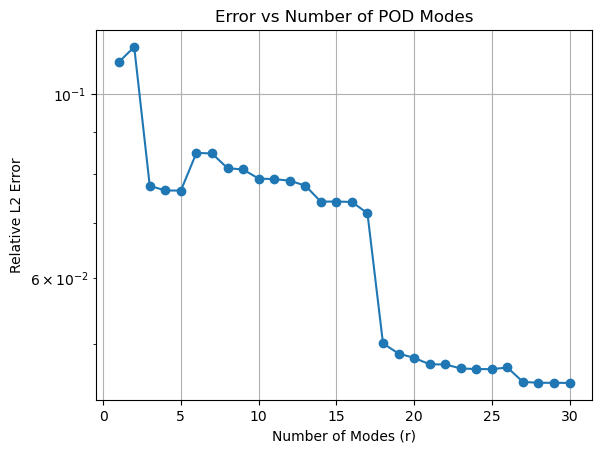

In [ ]:
error = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 31), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()

Error in A-norm with 1 modes: 1.0000e+00
Error in A-norm with 2 modes: 1.0000e+00
Error in A-norm with 3 modes: 1.0000e+00
Error in A-norm with 4 modes: 9.9456e-01
Error in A-norm with 5 modes: 9.9456e-01
Error in A-norm with 6 modes: 9.9456e-01
Error in A-norm with 7 modes: 9.9456e-01
Error in A-norm with 8 modes: 9.9411e-01
Error in A-norm with 9 modes: 9.9274e-01
Error in A-norm with 10 modes: 9.8840e-01
Error in A-norm with 11 modes: 9.8840e-01
Error in A-norm with 12 modes: 9.8401e-01
Error in A-norm with 13 modes: 9.8401e-01
Error in A-norm with 14 modes: 9.8069e-01
Error in A-norm with 15 modes: 9.8069e-01
Error in A-norm with 16 modes: 9.8069e-01
Error in A-norm with 17 modes: 9.8051e-01
Error in A-norm with 18 modes: 9.7913e-01
Error in A-norm with 19 modes: 9.7490e-01
Error in A-norm with 20 modes: 9.7490e-01
Error in A-norm with 21 modes: 9.7350e-01
Error in A-norm with 22 modes: 9.7328e-01
Error in A-norm with 23 modes: 9.7314e-01
Error in A-norm with 24 modes: 9.7180e-01
E

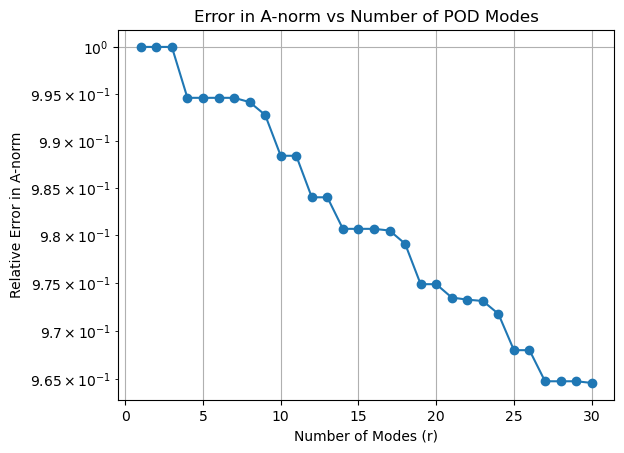

In [ ]:
def normeA(u, A):
    """Calcule la norme induite par A de la fonction u (version 100% FEniCS)."""
    # 1. On crée un vecteur FEniCS vide de la même taille que u
    Au = Vector(u.vector()) 
    
    # 2. FEniCS fait la multiplication Matrice * Vecteur (Au = A * u)
    A.mult(u.vector(), Au)
    
    # 3. FEniCS fait le produit scalaire u^T * (Au)
    norme_A = np.sqrt(u.vector().inner(Au)) 
    
    return norme_A
def error_A_norm(u1, u2, A):
    """Calcule l'erreur relative dans la norme induite par A entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return normeA(diff, A) / normeA(u1, A)
error_A = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error_A[r-1] = error_A_norm(u_full_fenics, u_approx_fenics, A_test)
    print(f"Error in A-norm with {r} modes: {error_A[r-1]:.4e}")


plt.figure()
plt.semilogy(range(1, 31), error_A, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative Error in A-norm')
plt.title('Error in A-norm vs Number of POD Modes')
plt.grid()
plt.show()

## CAS LINÉAIRE

Si on ne fait varier que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

On se rend compte que la dépendance en les paramettre est linaire ainsi la matrice $A$ du probleme peut etre construit comme tel :

$\mathbf{A} = D_{\text{frac}} \cdot \mathbf{A}_{\text{frac}} + D_{\text{back}} \cdot \mathbf{A}_{\text{back}}$

Où $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$ ne sont calculées que une fois.


In [ ]:
Ns_lineaire = 50
U_snapshot_lineaire = np.zeros((N_dof, Ns_lineaire))
print("dimension de U_snapshot:", U_snapshot_lineaire.shape)

dimension de U_snapshot: (160801, 50)


In [ ]:
parameters_list_lineaire = []
for i in tqdm(range(Ns_lineaire), desc="Génération des Snapshots"):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_lineaire)

Génération des Snapshots:   0%|          | 0/50 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   2%|▏         | 1/50 [00:04<03:53,  4.76s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   4%|▍         | 2/50 [00:08<03:31,  4.41s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  98%|█████████▊| 49/50 [03:16<00:04,  4.10s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots: 100%|██████████| 50/50 [03:20<00:00,  4.01s/it]

[{'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 104.96168258023567, 'D_fracture': 1.3017549513041464}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 105.98372101289624, 'D_fracture': 0.6673314783260105}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 99.01487330273406, 'D_fracture': 0.7421584695062893}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 84.53430508474446, 'D_fracture': 0.9998233641282865}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 118.2617229660046, 'D_fracture': 0.6801516430878942}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 100.69702790056488, 'D_fracture': 0.6094040005583956}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 89.25977167583154, 'D_fracture': 1.2600730979359878}, {'slope': 40.0, 'position': 70.0, 'half_width': 5.0, 'D_background': 99.92862429214509, 'D_fracture': 0.9767651759944858}, {'slope': 40

In [ ]:
U_l, S_l, Vt_l = np.linalg.svd(U_snapshot_lineaire, full_matrices=False)

number of singular values: 50
U shape: (160801, 50)
S shape: (50,)
Vt shape: (50, 50)
Singular values: [1.54591117e+03 6.47451108e+00 3.93654557e-02 3.65828686e-03
 2.97444236e-05 2.64328543e-06 4.42619253e-08 1.53013966e-09
 5.77618692e-10 3.70895637e-11 2.83652028e-11 2.22238940e-11
 1.32505078e-11 9.29577276e-12 7.00274314e-12 5.08074683e-12
 3.62648173e-12 3.22053156e-12 2.34782539e-12 1.52960159e-12
 1.37304494e-12 1.30228985e-12 1.29173048e-12 1.16656156e-12
 1.00709858e-12 9.71703605e-13 9.55136499e-13 8.83959412e-13
 7.86223767e-13 7.34426632e-13 6.75446329e-13 6.24410310e-13
 5.69203747e-13 5.33930028e-13 4.99734211e-13 4.48849767e-13
 4.27116109e-13 3.51124843e-13 3.45775163e-13 3.35178373e-13
 3.14129414e-13 3.06842873e-13 2.96436954e-13 2.93280203e-13
 2.89043439e-13 2.69954372e-13 2.69581562e-13 2.61925466e-13
 2.21172547e-13 1.96039367e-13]


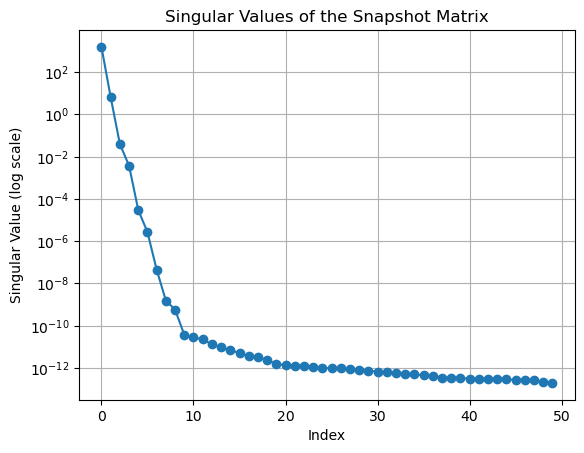

In [ ]:
print("number of singular values:", len(S_l))
print("U shape:", U_l.shape)
print("S shape:", S_l.shape)
print("Vt shape:", Vt_l.shape)
print("Singular values:", S_l)
plt.semilogy(S_l, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy (squared singular values): [2.38984135e+06 4.19192937e+01 1.54963910e-03 1.33830627e-05
 8.84730738e-10 6.98695785e-12 1.95911803e-15 2.34132737e-18
 3.33643353e-19 1.37563574e-21 8.04584731e-22 4.93901466e-22
 1.75575958e-22 8.64113912e-23 4.90384115e-23 2.58139884e-23
 1.31513697e-23 1.03718235e-23 5.51228407e-24 2.33968101e-24
 1.88525241e-24 1.69595886e-24 1.66856764e-24 1.36086588e-24
 1.01424755e-24 9.44207896e-25 9.12285733e-25 7.81384241e-25
 6.18147811e-25 5.39382477e-25 4.56227743e-25 3.89888235e-25
 3.23992905e-25 2.85081275e-25 2.49734281e-25 2.01466113e-25
 1.82428171e-25 1.23288656e-25 1.19560463e-25 1.12344542e-25
 9.86772885e-26 9.41525486e-26 8.78748675e-26 8.60132774e-26
 8.35461098e-26 7.28753629e-26 7.26742186e-26 6.86049495e-26
 4.89172954e-26 3.84314332e-26]
Cumulative energy: [2389841.35010568 2389883.2693994  2389883.27094904 2389883.27096242
 2389883.27096242 2389883.27096242 2389883.27096242 2389883.27096242
 2389883.27096242 2389883.27096242 2389883.27

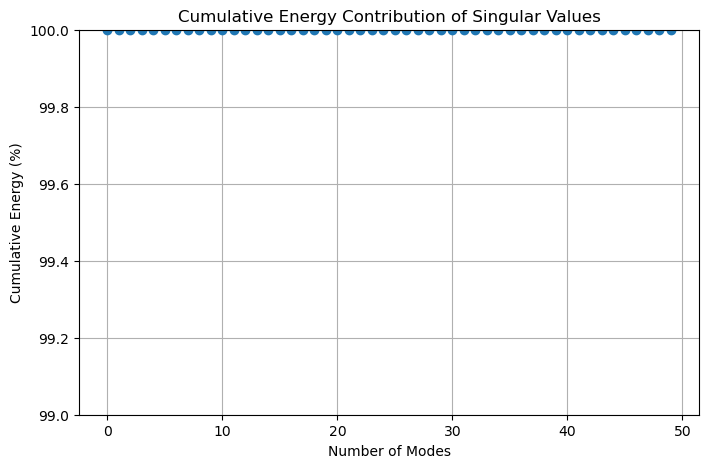

In [ ]:
plot_energy_contribution(S_l)

In [ ]:
N_test = 10
parameters_test_lineaire_list = []
for i in range(N_test):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_lineaire_list.append(parameters)

In [ ]:
Ns_lineaire_range = [1, 3, 6, 9, 20, 50]#range(1, 52, 10)
error_A_lineaire = np.zeros(len(Ns_lineaire_range))
time_linear = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list = []
b_test_list = []
HF_sol_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):
        A_test = A_test_list[i]
        b_test = b_test_list[i]
        u_full = HF_sol_list[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        V_r = U_l[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire[j] /= len(parameters_test_lineaire_list) 
    time_linear[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire[j]:.4e} | Time: {time_linear[j]:.4e} s")


Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with linear snapshots:  17%|█▋        | 1/6 [00:00<00:01,  4.24it/s]

Error in A-norm with 1 modes: 2.6267e-04 | Time: 1.2177e-02 s


Testing ROM with linear snapshots:  33%|███▎      | 2/6 [00:00<00:01,  3.22it/s]

Error in A-norm with 3 modes: 3.5181e-07 | Time: 2.4887e-02 s


...

Error in A-norm with 9 modes: 4.6797e-14 | Time: 3.6779e-02 s


Testing ROM with linear snapshots:  83%|████████▎ | 5/6 [00:02<00:00,  2.11it/s]

Error in A-norm with 20 modes: 4.2036e-14 | Time: 4.6915e-02 s


Testing ROM with linear snapshots: 100%|██████████| 6/6 [00:13<00:00,  2.31s/it]

Error in A-norm with 50 modes: 4.4599e-14 | Time: 1.1628e+00 s


In [ ]:
HF_compution_time = 0
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time += time() - t
HF_compution_time /= N_test
print(f"Average time for HF computation: {HF_compution_time:.4f} seconds")


Average time for HF computation: 1.2495 seconds


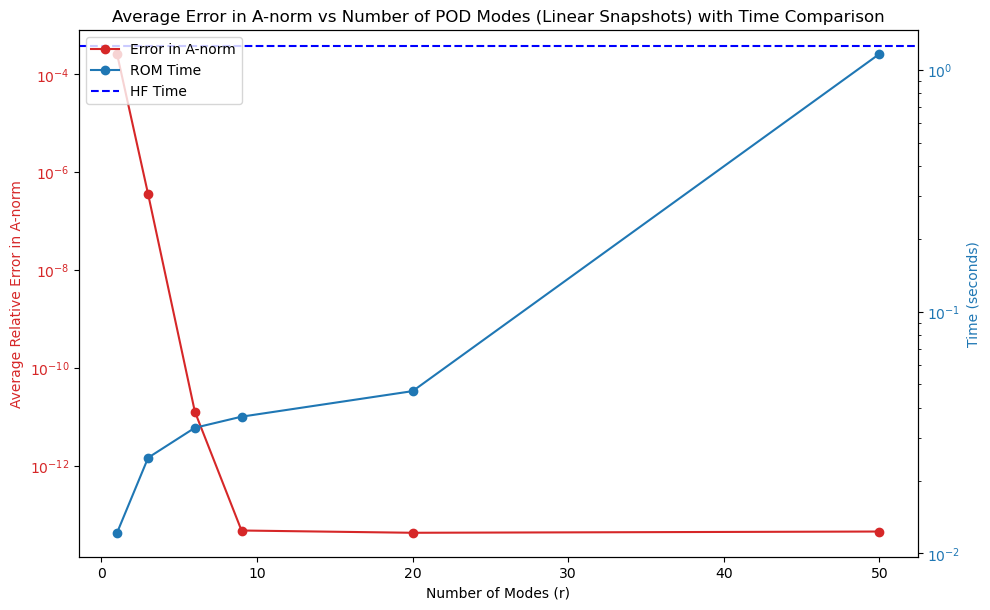

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()
